# Imports 

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import numpy as np
import time

# 1. Configuration and Device Setup

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 20  # Increased for clearer overfitting/generalization

print(f"Using device: {DEVICE}")

Using device: cuda


# 2. Data Preparation (Overfit vs Regularized)

In [9]:
# Base transforms (No augmentation - used for overfitting and validation)
transform_base = transforms.Compose([
    transforms.Resize((224, 224)),  # Match ResNet18 pretraining size
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Augmented transforms (Used for the regularized model)
transform_augmented = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),  # Data Augmentation
    transforms.Resize((224, 224)),  # Resize after augmentations
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Datasets
trainset_overfit = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_base)
trainset_reg = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_augmented)
valset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_base)

# Use a smaller subset for the overfitting model to exaggerate overfitting
subset_size = 5000  # You can reduce to 1000 for even stronger overfitting
indices = torch.randperm(len(trainset_overfit))[:subset_size]
trainset_overfit_small = torch.utils.data.Subset(trainset_overfit, indices)

# DataLoaders
trainloader_overfit = torch.utils.data.DataLoader(trainset_overfit_small, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
trainloader_reg = torch.utils.data.DataLoader(trainset_reg, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)



# 3. Model Definitions

In [10]:
def get_overfitting_model():
    """Model designed to overfit: All layers trainable, overly complex classifier."""
    model = models.resnet18(pretrained=True)
    num_ftrs = model.fc.in_features
    
    # Overly complex head to memorize training data
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 1024),
        nn.ReLU(),
        nn.Linear(1024, 10)
    )
    return model.to(DEVICE)

def get_regularized_model():
    """Model designed to generalize: Simpler head, BN, Dropout, and Augmentation."""
    model = models.resnet18(pretrained=True)
    
    # FIX: We REMOVED the freezing loop. 
    # Let the whole network train so it can adapt to 32x32 images.
        
    num_ftrs = model.fc.in_features
    
    # Strategy: Reduced complexity, Batch Normalization, and Dropout
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 256),       
        nn.BatchNorm1d(256),            
        nn.ReLU(),
        nn.Dropout(p=0.4),              # Slightly reduced dropout from 0.5 to 0.4
        nn.Linear(256, 10)
    )
    return model.to(DEVICE)

# 4. Training and Evaluation Loop

In [11]:
def train_and_evaluate(model, trainloader, valloader, epochs, title):
    criterion = nn.CrossEntropyLoss()
    # Only optimize parameters that require gradients (handles the frozen layers)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    print(f"\n--- Training {title} ---")
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        train_loss = running_loss / len(trainloader)
        train_acc = correct / total
        
        # Validation Phase
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        all_preds, all_targets = [], []
        
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(labels.cpu().numpy())
                
        val_loss = val_loss / len(valloader)
        val_acc = correct / total
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
              
    # Calculate final F1 Score
    final_f1 = f1_score(all_targets, all_preds, average='macro')
    print(f"Final Validation Macro F1-Score: {final_f1:.4f}")
    
    return history

# 5. Execution and Plotting

c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



--- Training Overfitting Model ---
Epoch 1/20 | Train Loss: 1.2098 Acc: 0.5798 | Val Loss: 1.0727 Acc: 0.6521
Epoch 2/20 | Train Loss: 0.8587 Acc: 0.7050 | Val Loss: 1.3277 Acc: 0.5986
Epoch 3/20 | Train Loss: 0.6521 Acc: 0.7824 | Val Loss: 1.1897 Acc: 0.6628
Epoch 4/20 | Train Loss: 0.5013 Acc: 0.8336 | Val Loss: 0.9591 Acc: 0.7081
Epoch 5/20 | Train Loss: 0.4006 Acc: 0.8644 | Val Loss: 0.7959 Acc: 0.7446
Epoch 6/20 | Train Loss: 0.2953 Acc: 0.9020 | Val Loss: 1.0763 Acc: 0.7186
Epoch 7/20 | Train Loss: 0.2633 Acc: 0.9144 | Val Loss: 1.2632 Acc: 0.6859
Epoch 8/20 | Train Loss: 0.2580 Acc: 0.9160 | Val Loss: 0.9125 Acc: 0.7703
Epoch 9/20 | Train Loss: 0.1925 Acc: 0.9342 | Val Loss: 0.9644 Acc: 0.7480
Epoch 10/20 | Train Loss: 0.1678 Acc: 0.9504 | Val Loss: 0.8873 Acc: 0.7704
Epoch 11/20 | Train Loss: 0.1235 Acc: 0.9598 | Val Loss: 1.1018 Acc: 0.7429
Epoch 12/20 | Train Loss: 0.1555 Acc: 0.9512 | Val Loss: 0.9778 Acc: 0.7581
Epoch 13/20 | Train Loss: 0.0800 Acc: 0.9756 | Val Loss: 1.03

c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\belw2\Desktop\ALL\ML && DL\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20 | Train Loss: 0.9569 Acc: 0.6740 | Val Loss: 0.6887 Acc: 0.7728
Epoch 2/20 | Train Loss: 0.6457 Acc: 0.7820 | Val Loss: 0.5063 Acc: 0.8295
Epoch 3/20 | Train Loss: 0.5345 Acc: 0.8220 | Val Loss: 0.4256 Acc: 0.8562
Epoch 4/20 | Train Loss: 0.4728 Acc: 0.8400 | Val Loss: 0.3808 Acc: 0.8727
Epoch 5/20 | Train Loss: 0.4239 Acc: 0.8559 | Val Loss: 0.3265 Acc: 0.8893
Epoch 6/20 | Train Loss: 0.3795 Acc: 0.8703 | Val Loss: 0.3132 Acc: 0.8921
Epoch 7/20 | Train Loss: 0.3501 Acc: 0.8820 | Val Loss: 0.3059 Acc: 0.8974
Epoch 8/20 | Train Loss: 0.3205 Acc: 0.8904 | Val Loss: 0.2859 Acc: 0.9059
Epoch 9/20 | Train Loss: 0.2996 Acc: 0.8992 | Val Loss: 0.2466 Acc: 0.9174
Epoch 10/20 | Train Loss: 0.2781 Acc: 0.9059 | Val Loss: 0.2434 Acc: 0.9170
Epoch 11/20 | Train Loss: 0.2605 Acc: 0.9117 | Val Loss: 0.2532 Acc: 0.9144
Epoch 12/20 | Train Loss: 0.2472 Acc: 0.9169 | Val Loss: 0.2522 Acc: 0.9149
Epoch 13/20 | Train Loss: 0.2308 Acc: 0.9212 | Val Loss: 0.2261 Acc: 0.9245
Epoch 14/20 | Train L

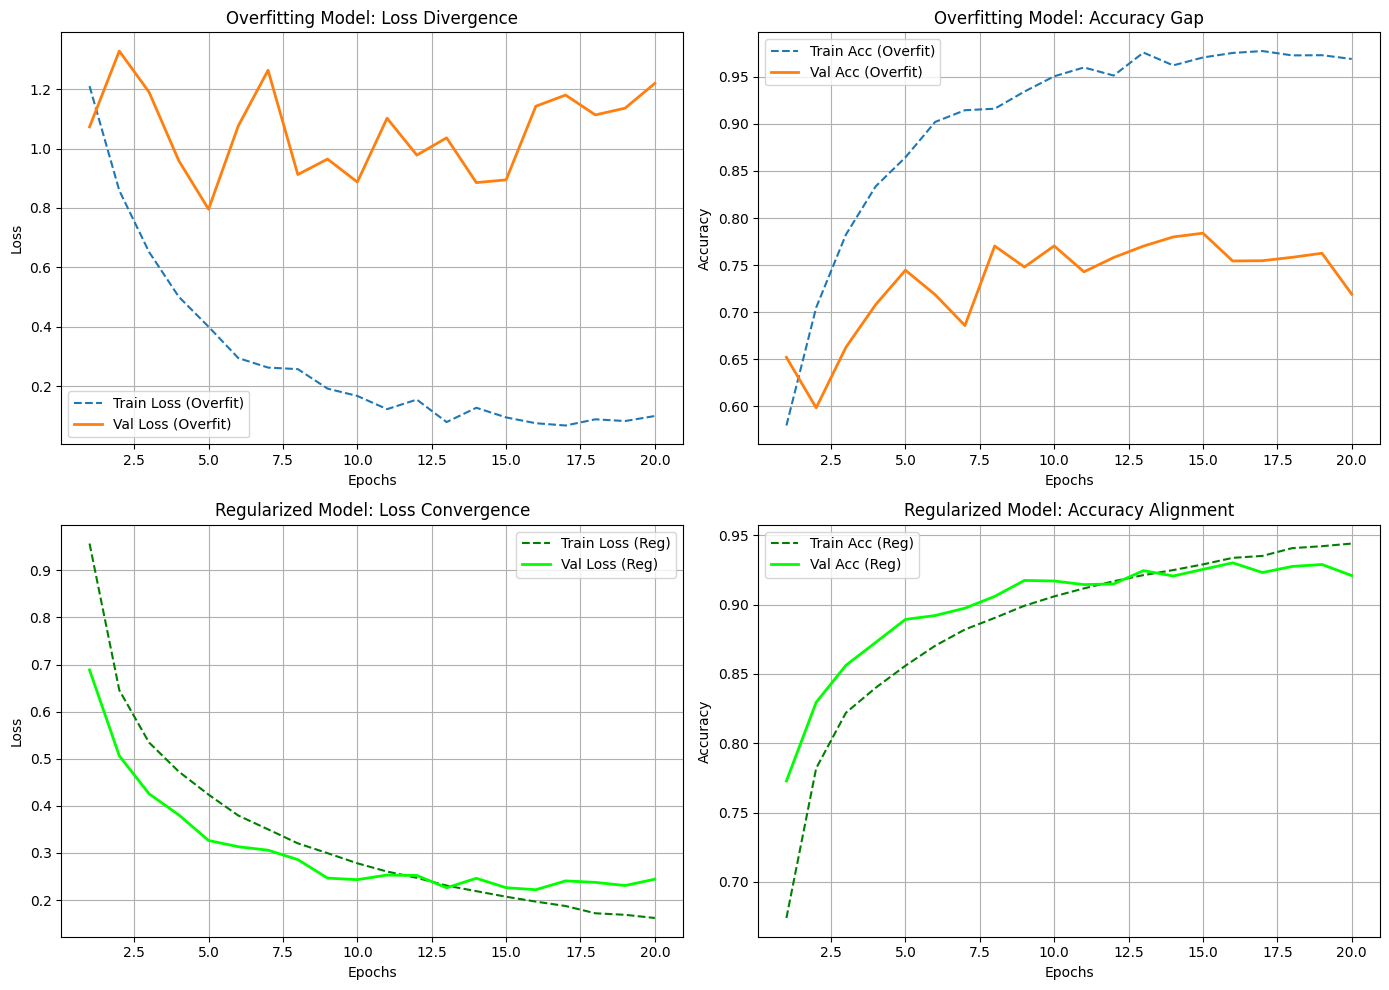

In [12]:
# Train Model 1: Overfitting
model_overfit = get_overfitting_model()
hist_overfit = train_and_evaluate(model_overfit, trainloader_overfit, valloader, EPOCHS, "Overfitting Model")

# Train Model 2: Regularized
model_reg = get_regularized_model()
hist_reg = train_and_evaluate(model_reg, trainloader_reg, valloader, EPOCHS, "Regularized Model")

# Plotting the results
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(14, 10))

# Loss Curves
plt.subplot(2, 2, 1)
plt.plot(epochs_range, hist_overfit['train_loss'], label='Train Loss (Overfit)', linestyle='--')
plt.plot(epochs_range, hist_overfit['val_loss'], label='Val Loss (Overfit)', linewidth=2)
plt.title('Overfitting Model: Loss Divergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Curves
plt.subplot(2, 2, 2)
plt.plot(epochs_range, hist_overfit['train_acc'], label='Train Acc (Overfit)', linestyle='--')
plt.plot(epochs_range, hist_overfit['val_acc'], label='Val Acc (Overfit)', linewidth=2)
plt.title('Overfitting Model: Accuracy Gap')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Regularized Loss Curves
plt.subplot(2, 2, 3)
plt.plot(epochs_range, hist_reg['train_loss'], label='Train Loss (Reg)', linestyle='--', color='green')
plt.plot(epochs_range, hist_reg['val_loss'], label='Val Loss (Reg)', linewidth=2, color='lime')
plt.title('Regularized Model: Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Regularized Accuracy Curves
plt.subplot(2, 2, 4)
plt.plot(epochs_range, hist_reg['train_acc'], label='Train Acc (Reg)', linestyle='--', color='green')
plt.plot(epochs_range, hist_reg['val_acc'], label='Val Acc (Reg)', linewidth=2, color='lime')
plt.title('Regularized Model: Accuracy Alignment')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()